# AAA_t_test5: scalar filtered data with AAA_tube

This notebook is similar to `AAA_t_test4`, but it first computes `G_sce`, `G_wce`, and exact data on the source complex tube. It then builds filtered scalar training data separately for `G_00` and `G_01`, and fits separate `AAA_tube` interpolants for those two matrix elements.


In [40]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_complex_interpolation_workflow import (
    compute_exact_t,
    compute_sce_t,
    compute_wce_t,
    build_t_app_G_app_scalar,
)
from _bary_rational import AAA_tube, AAA_tube_v2


In [41]:
# Hubbard dimer and Matsubara setup. Same defaults as AAA_t_test4.
beta = 5.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

U = 8.0
T = 20.0
sce_order = 4
wce_order = 12
epsilon = 1e-6
# Select one Matsubara frequency.
n_fit = Nw - 1
print("selected Matsubara index:", n_fit)
print("selected omega:", wn[n_fit])


selected Matsubara index: 19
selected omega: -0.6283185307179586


In [42]:
# Source tube for evaluating exact/SCE/WCE and filtering scalar t_app, G_app.
source_tube_real_window = (-T, T)
source_tube_delta = 1
source_N_real = 501
source_N_imag = 101

# Separate AAA_tube pole/boundary constraint settings.
aaa_tube_real_window = (-T, T)
aaa_tube_delta = 0.2
aaa_tube_Ns = 100000
max_terms = 50
max_error = epsilon

# Full tube where the final AAA interpolant is evaluated and compared to exact.
eval_tube_real_window = (-T, T)
eval_tube_delta = 1
eval_N_real = 501
eval_N_imag = 101


In [43]:
def make_tube_lattice(real_window, delta, n_real, n_imag):
    lo, hi = real_window
    real_axis = np.linspace(lo, hi, n_real)
    imag_axis = np.linspace(-delta, delta, n_imag)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)
    t_grid = real_grid + 1j * imag_grid
    return real_grid, imag_grid, t_grid


def tube_boundary(real_window, delta):
    lo, hi = real_window
    return np.array([
        lo - 1j * delta,
        hi - 1j * delta,
        hi + 1j * delta,
        lo + 1j * delta,
        lo - 1j * delta,
    ])


def lattice_field_from_points(t_points, values, real_grid, imag_grid):
    field = np.full(real_grid.shape, np.nan, dtype=float)
    real_axis = real_grid[0]
    imag_axis = imag_grid[:, 0]
    real_step = real_axis[1] - real_axis[0]
    imag_step = imag_axis[1] - imag_axis[0]

    real_idx = np.rint((t_points.real - real_axis[0]) / real_step).astype(int)
    imag_idx = np.rint((t_points.imag - imag_axis[0]) / imag_step).astype(int)
    in_bounds = (
        (real_idx >= 0) & (real_idx < real_axis.size)
        & (imag_idx >= 0) & (imag_idx < imag_axis.size)
    )
    field[imag_idx[in_bounds], real_idx[in_bounds]] = values[in_bounds]
    return field


In [44]:
# Build the source tube grid and compute exact/SCE/WCE on that grid.
source_real_grid, source_imag_grid, source_t_grid = make_tube_lattice(
    source_tube_real_window,
    source_tube_delta,
    source_N_real,
    source_N_imag,
)
source_t_values = source_t_grid.ravel()
source_boundary = tube_boundary(source_tube_real_window, source_tube_delta)
wn_single = np.array([wn[n_fit]])

G_exact_source = compute_exact_t(source_t_values, wn_single, U, beta)[:, 0]
G_sce_source = compute_sce_t(sce_order, source_t_values, wn_single, U, beta)[:, 0]
G_wce_source = compute_wce_t(wce_order, source_t_values, wn_single, U)[:, 0]

print("source tube grid shape:", source_t_grid.shape)
print("source tube point count:", source_t_values.size)
print("G_exact_source shape:", G_exact_source.shape)
print("G_sce_source shape:", G_sce_source.shape)
print("G_wce_source shape:", G_wce_source.shape)


source tube grid shape: (101, 501)
source tube point count: 50601
G_exact_source shape: (50601, 2, 2)
G_sce_source shape: (50601, 2, 2)
G_wce_source shape: (50601, 2, 2)


In [45]:
# Build filtered scalar training data separately for G_00 and G_01.
t_app_00, G_app_00 = build_t_app_G_app_scalar(
    G_sce_source[:, 0, 0],
    G_wce_source[:, 0, 0],
    G_exact_source[:, 0, 0],
    source_t_values,
    epsilon,
)

t_app_01, G_app_01 = build_t_app_G_app_scalar(
    G_sce_source[:, 0, 1],
    G_wce_source[:, 0, 1],
    G_exact_source[:, 0, 1],
    source_t_values,
    epsilon,
)

G_exact_app_00 = compute_exact_t(t_app_00, wn_single, U, beta)[:, 0, 0, 0]
G_exact_app_01 = compute_exact_t(t_app_01, wn_single, U, beta)[:, 0, 0, 1]
err_app_00 = np.abs(G_app_00 - G_exact_app_00)
err_app_01 = np.abs(G_app_01 - G_exact_app_01)

print("G_00 t_app shape:", t_app_00.shape, "max error:", np.max(err_app_00) if err_app_00.size else np.nan)
print("G_01 t_app shape:", t_app_01.shape, "max error:", np.max(err_app_01) if err_app_01.size else np.nan)
print("epsilon:", epsilon)


Selected scalar complex t points: 37609 of 50601 | SCE valid: 163 | WCE valid: 37446
Selected scalar complex t points: 37411 of 50601 | SCE valid: 29 | WCE valid: 37382
G_00 t_app shape: (37609,) max error: 9.998564056411428e-07
G_01 t_app shape: (37411,) max error: 9.952260743312108e-07
epsilon: 1e-06


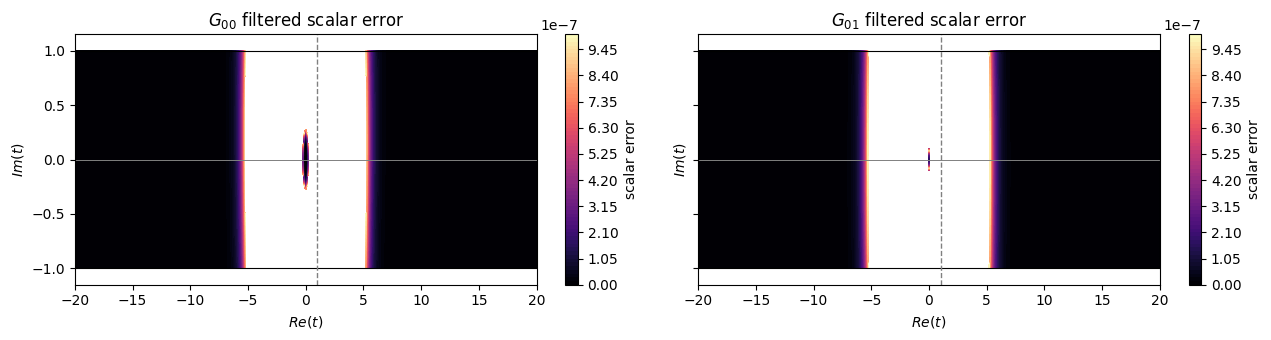

In [46]:
# Visualize the scalar filtered source points used for AAA fitting.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharex=True, sharey=True)
filtered_sets = [
    (t_app_00, err_app_00, r"$G_{00}$ filtered scalar error"),
    (t_app_01, err_app_01, r"$G_{01}$ filtered scalar error"),
]

for ax, (t_app, err_app, title) in zip(axes, filtered_sets):
    field = lattice_field_from_points(t_app, err_app, source_real_grid, source_imag_grid)
    cf = ax.contourf(source_real_grid, source_imag_grid, field, levels=80, cmap="magma")
    ax.plot(source_boundary.real, source_boundary.imag, color="k", linewidth=0.8)
    ax.axhline(0, color="0.5", linewidth=0.7)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(r"$Re(t)$")
    ax.set_ylabel(r"$Im(t)$")
    ax.set_ylim(-1.15 * source_tube_delta, 1.15 * source_tube_delta)
    fig.colorbar(cf, ax=ax, label="scalar error")

fig.tight_layout()
plt.show()


In [47]:
# Fit scalar AAA_tube interpolants for G_00 and G_01 using their own filtered data.
r00 = AAA_tube(
    t_app_00,
    G_app_00,
    rtol=max_error,
    max_terms=max_terms,
    delta=0.2,
    Ns=aaa_tube_Ns,
    tube_real_window=aaa_tube_real_window,
)

r01 = AAA_tube(
    t_app_01,
    G_app_01,
    rtol=max_error,
    max_terms=max_terms,
    delta=0.2,
    Ns=aaa_tube_Ns,
    tube_real_window=aaa_tube_real_window,
)


AAA_tube final poles: [ 0.40481978+2.50260338j -0.43763692+2.43681614j  0.45252306-2.62642606j
 -0.5618556 -2.44285367j  1.04615726-0.97677871j  1.00078402+0.62860624j
 -1.26074145-0.84365206j -1.15224962+0.60787387j]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.2
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.0469511190900366
AAA_tube final max_error: 7.160256326875684e-07
AAA_tube target max_error: 1e-06
AAA_tube final poles: [ 7.54233577e+00-51.26040804j  2.38214529e-03 +2.56522678j
  2.41826130e+00 +1.05694576j  2.41856532e+00 -0.99105455j
 -2.43534660e+00 +1.02612282j -2.49513712e-03 -2.57221253j
 -2.42531490e+00 -1.0265686j   7.22189041e-01 +1.51269209j
 -7.09524431e-01 +1.51719525j  1.33908612e+00 +0.64810093j
  1.34317909e+00 -0.69103235j  7.13876694e-01 -1.54163466j
 -1.33075348e+00 +0.66154034j -7.21473690e-01 -1.53523687j
 -1.34087292e+00 -0.6779216j ]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.2
AAA_tube poles 

In [48]:
# Evaluate exact and AAA interpolation on the full evaluation tube.
eval_real_grid, eval_imag_grid, eval_t_grid = make_tube_lattice(
    eval_tube_real_window,
    eval_tube_delta,
    eval_N_real,
    eval_N_imag,
)
eval_t_values = eval_t_grid.ravel()
eval_boundary = tube_boundary(eval_tube_real_window, eval_tube_delta)

G_exact_eval = compute_exact_t(eval_t_values, wn_single, U, beta)[:, 0]
G00_aaa_eval = r00(eval_t_values)
G01_aaa_eval = r01(eval_t_values)

print("evaluation tube grid shape:", eval_t_grid.shape)
print("evaluation point count:", eval_t_values.size)
print("G_exact_eval shape:", G_exact_eval.shape)


evaluation tube grid shape: (101, 501)
evaluation point count: 50601
G_exact_eval shape: (50601, 2, 2)


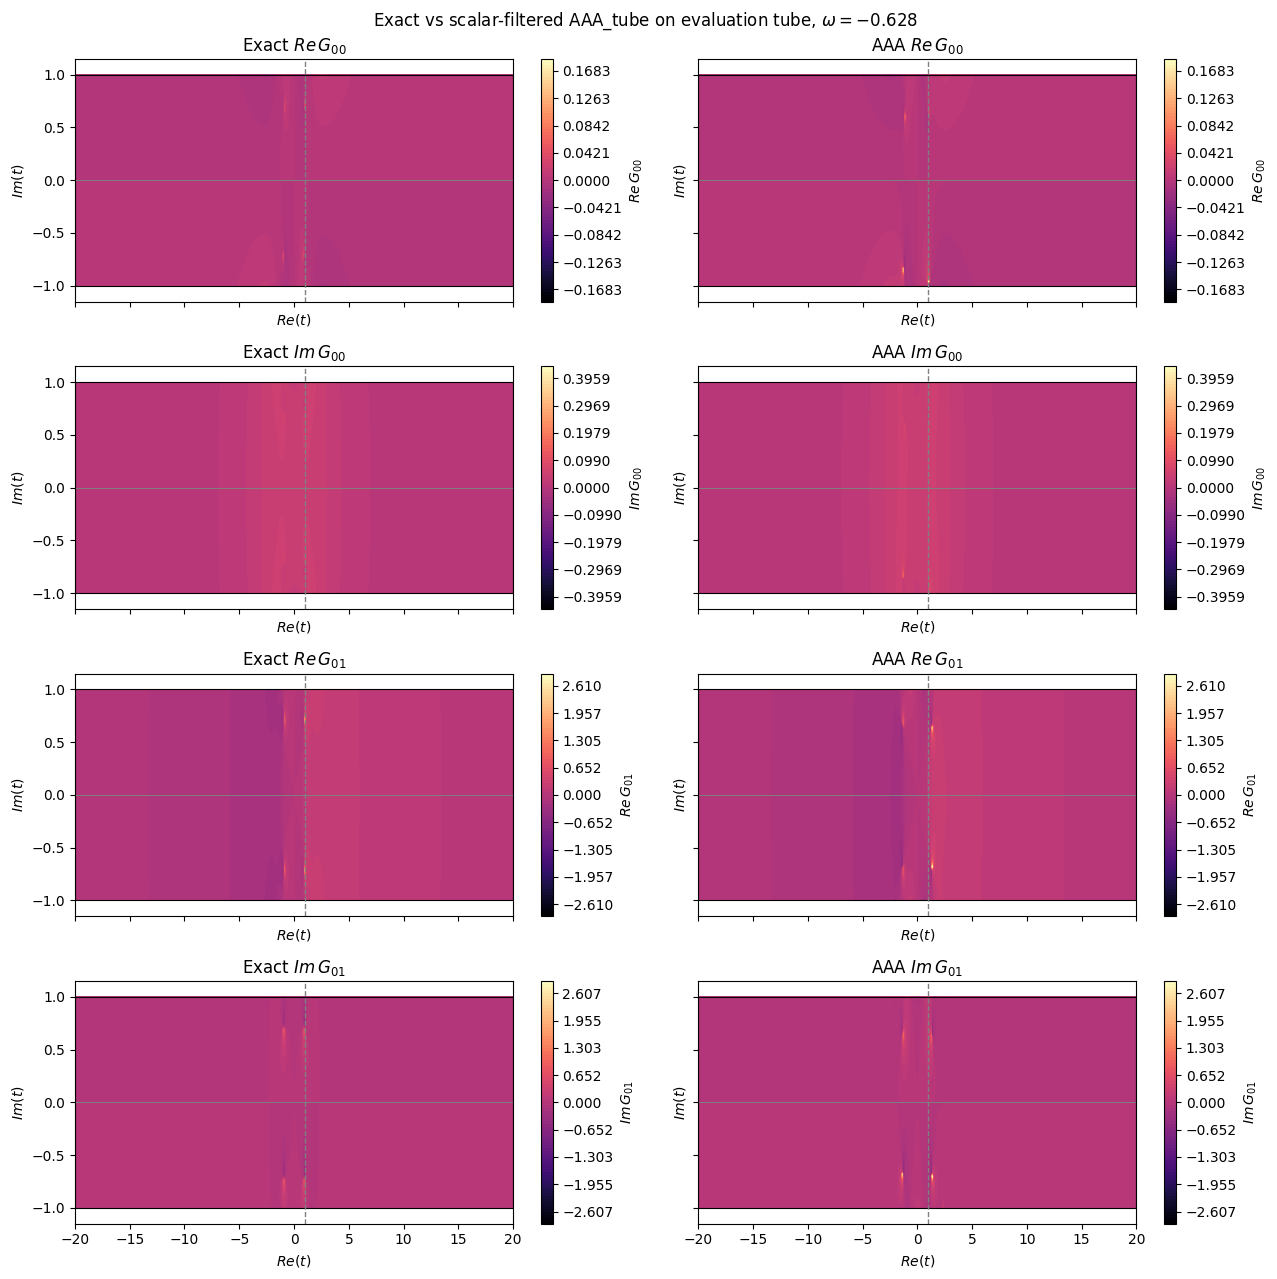

In [49]:
# Exact on the left, AAA interpolation on the right over the whole evaluation tube.
comparison_components = [
    (G_exact_eval[:, 0, 0].real, G00_aaa_eval.real, r"$Re\,G_{00}$"),
    (G_exact_eval[:, 0, 0].imag, G00_aaa_eval.imag, r"$Im\,G_{00}$"),
    (G_exact_eval[:, 0, 1].real, G01_aaa_eval.real, r"$Re\,G_{01}$"),
    (G_exact_eval[:, 0, 1].imag, G01_aaa_eval.imag, r"$Im\,G_{01}$"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 13), sharex=True, sharey=True)
for row, (exact_values, aaa_values, title) in enumerate(comparison_components):
    exact_field = exact_values.reshape(eval_real_grid.shape)
    aaa_field = aaa_values.reshape(eval_real_grid.shape)
    vmax = np.nanmax(np.abs([exact_field, aaa_field]))
    levels = np.linspace(-vmax, vmax, 81) if vmax > 0 else 80

    panels = [
        (exact_field, "Exact " + title),
        (aaa_field, "AAA " + title),
    ]
    for col, (field, panel_title) in enumerate(panels):
        ax = axes[row, col]
        cf = ax.contourf(eval_real_grid, eval_imag_grid, field, levels=levels, cmap="magma")
        ax.plot(eval_boundary.real, eval_boundary.imag, color="k", linewidth=0.8)
        ax.axhline(0, color="0.5", linewidth=0.7)
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_title(panel_title)
        ax.set_xlabel(r"$Re(t)$")
        ax.set_ylabel(r"$Im(t)$")
        ax.set_ylim(-1.15 * eval_tube_delta, 1.15 * eval_tube_delta)
        fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"Exact vs scalar-filtered AAA_tube on evaluation tube, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


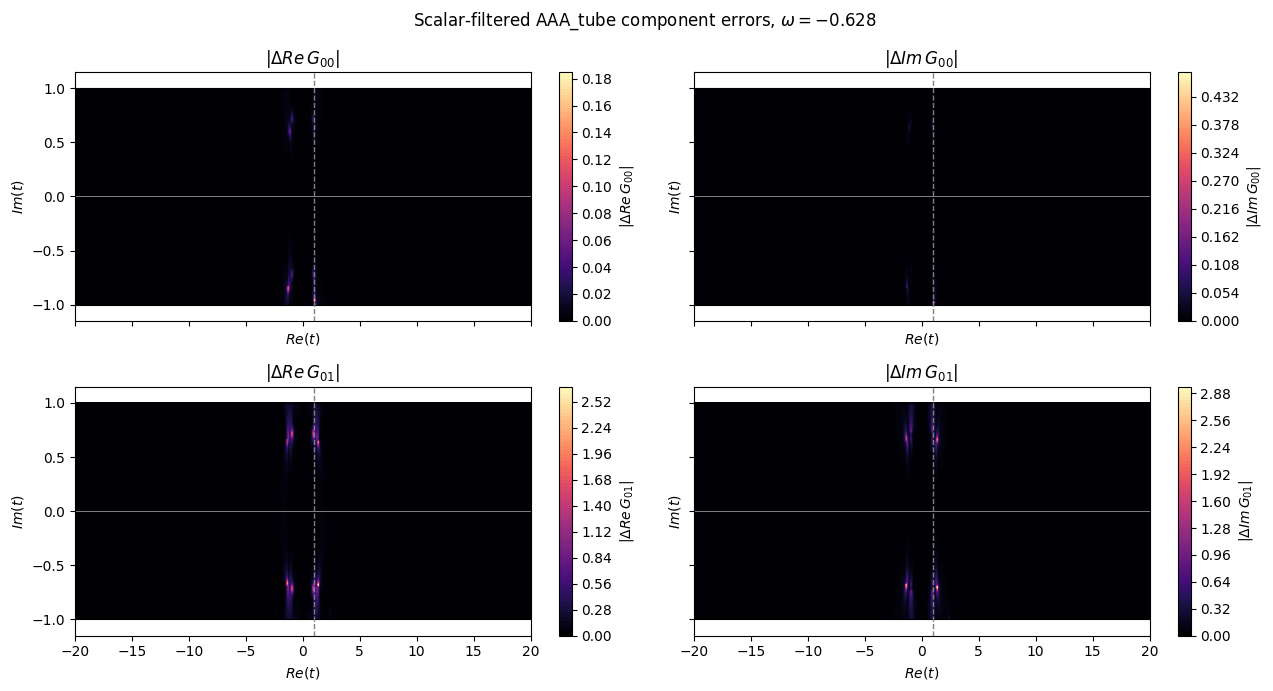

In [50]:
# Component error of the AAA interpolation on the whole evaluation tube.
error_components = [
    (np.abs(G00_aaa_eval.real - G_exact_eval[:, 0, 0].real), r"$|\Delta Re\,G_{00}|$"),
    (np.abs(G00_aaa_eval.imag - G_exact_eval[:, 0, 0].imag), r"$|\Delta Im\,G_{00}|$"),
    (np.abs(G01_aaa_eval.real - G_exact_eval[:, 0, 1].real), r"$|\Delta Re\,G_{01}|$"),
    (np.abs(G01_aaa_eval.imag - G_exact_eval[:, 0, 1].imag), r"$|\Delta Im\,G_{01}|$"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for ax, (values, title) in zip(axes.ravel(), error_components):
    field = values.reshape(eval_real_grid.shape)
    cf = ax.contourf(eval_real_grid, eval_imag_grid, field, levels=80, cmap="magma")
    ax.plot(eval_boundary.real, eval_boundary.imag, color="k", linewidth=0.8)
    ax.axhline(0, color="0.5", linewidth=0.7)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(r"$Re(t)$")
    ax.set_ylabel(r"$Im(t)$")
    ax.set_ylim(-1.15 * eval_tube_delta, 1.15 * eval_tube_delta)
    fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"Scalar-filtered AAA_tube component errors, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


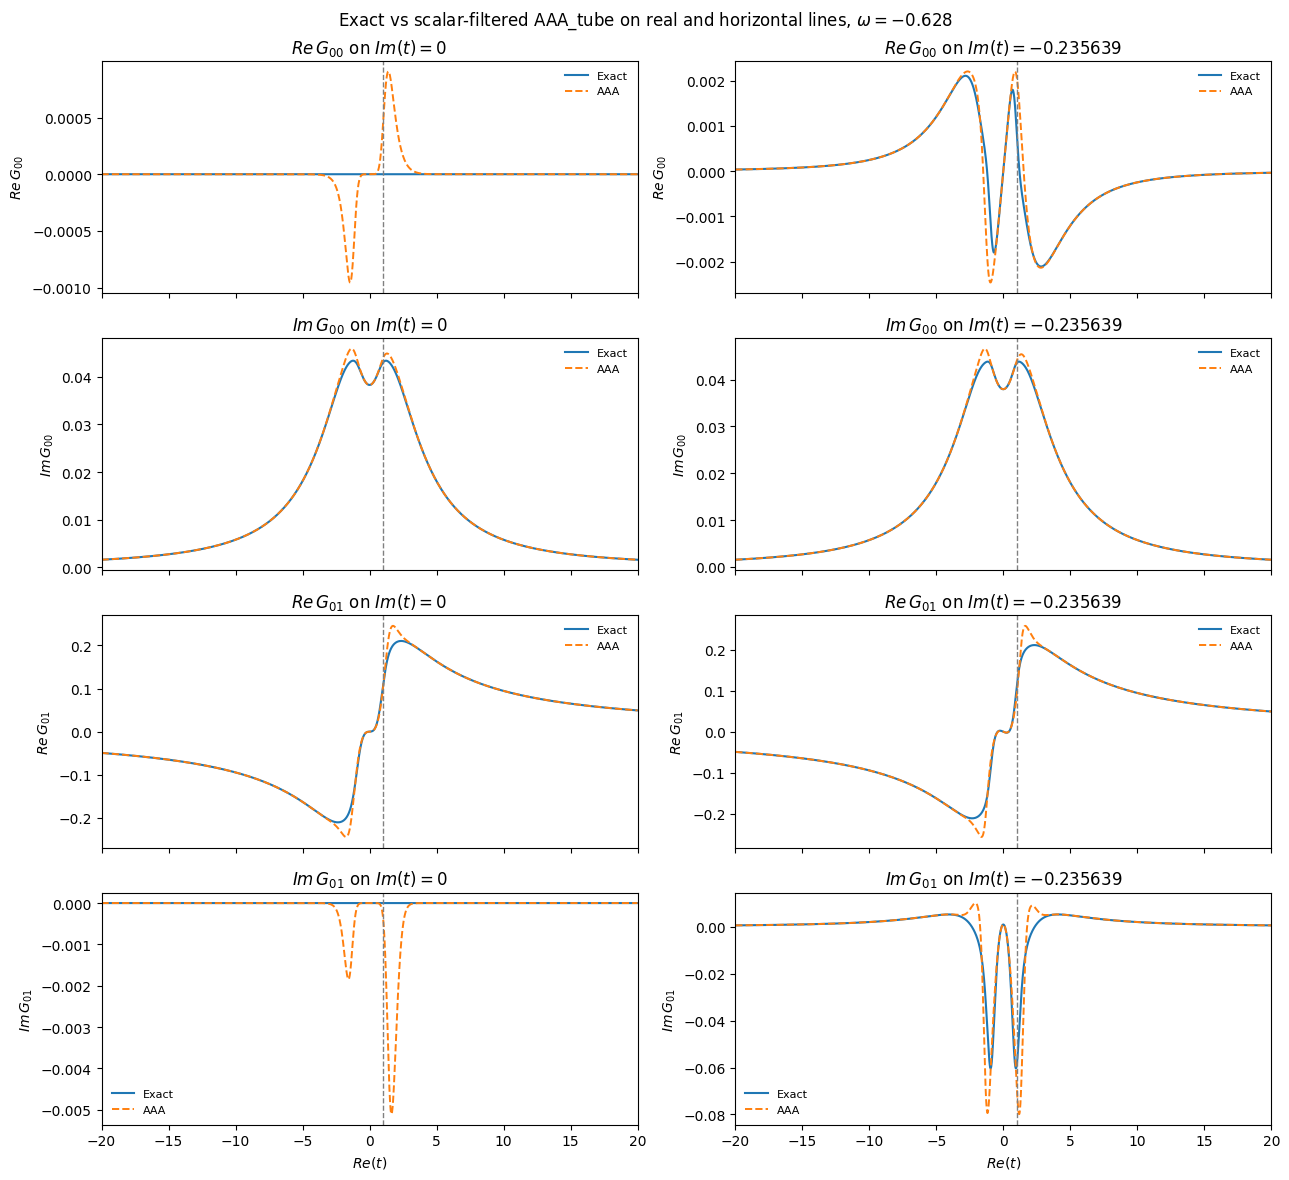

In [51]:
# Compare AAA and exact on one-dimensional paths.
Nt = 2001
eta = -0.23563899

t_line_real = np.linspace(-T, T, Nt)
t_line_complex = t_line_real + eta * 1j

G_exact_line_real = compute_exact_t(t_line_real, wn_single, U, beta)[:, 0]
G_exact_line_complex = compute_exact_t(t_line_complex, wn_single, U, beta)[:, 0]

G00_aaa_line_real = r00(t_line_real)
G01_aaa_line_real = r01(t_line_real)
G00_aaa_line_complex = r00(t_line_complex)
G01_aaa_line_complex = r01(t_line_complex)

line_components = [
    (G_exact_line_real[:, 0, 0].real, G00_aaa_line_real.real, G_exact_line_complex[:, 0, 0].real, G00_aaa_line_complex.real, r"$Re\,G_{00}$"),
    (G_exact_line_real[:, 0, 0].imag, G00_aaa_line_real.imag, G_exact_line_complex[:, 0, 0].imag, G00_aaa_line_complex.imag, r"$Im\,G_{00}$"),
    (G_exact_line_real[:, 0, 1].real, G01_aaa_line_real.real, G_exact_line_complex[:, 0, 1].real, G01_aaa_line_complex.real, r"$Re\,G_{01}$"),
    (G_exact_line_real[:, 0, 1].imag, G01_aaa_line_real.imag, G_exact_line_complex[:, 0, 1].imag, G01_aaa_line_complex.imag, r"$Im\,G_{01}$"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for row, (exact_real, aaa_real, exact_complex, aaa_complex, title) in enumerate(line_components):
    axes[row, 0].plot(t_line_real, exact_real, color="tab:blue", linewidth=1.5, label="Exact")
    axes[row, 0].plot(t_line_real, aaa_real, color="tab:orange", linestyle="--", linewidth=1.4, label="AAA")
    axes[row, 0].set_title(title + r" on $Im(t)=0$")

    axes[row, 1].plot(t_line_real, exact_complex, color="tab:blue", linewidth=1.5, label="Exact")
    axes[row, 1].plot(t_line_real, aaa_complex, color="tab:orange", linestyle="--", linewidth=1.4, label="AAA")
    axes[row, 1].set_title(title + rf" on $Im(t)={eta:g}$")

    for ax in axes[row, :]:
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(-T, T)
        # ax.set_ylim(-0.5, 0.5)
        ax.set_ylabel(title)
        ax.legend(frameon=False, fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$Re(t)$")

fig.suptitle(rf"Exact vs scalar-filtered AAA_tube on real and horizontal lines, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


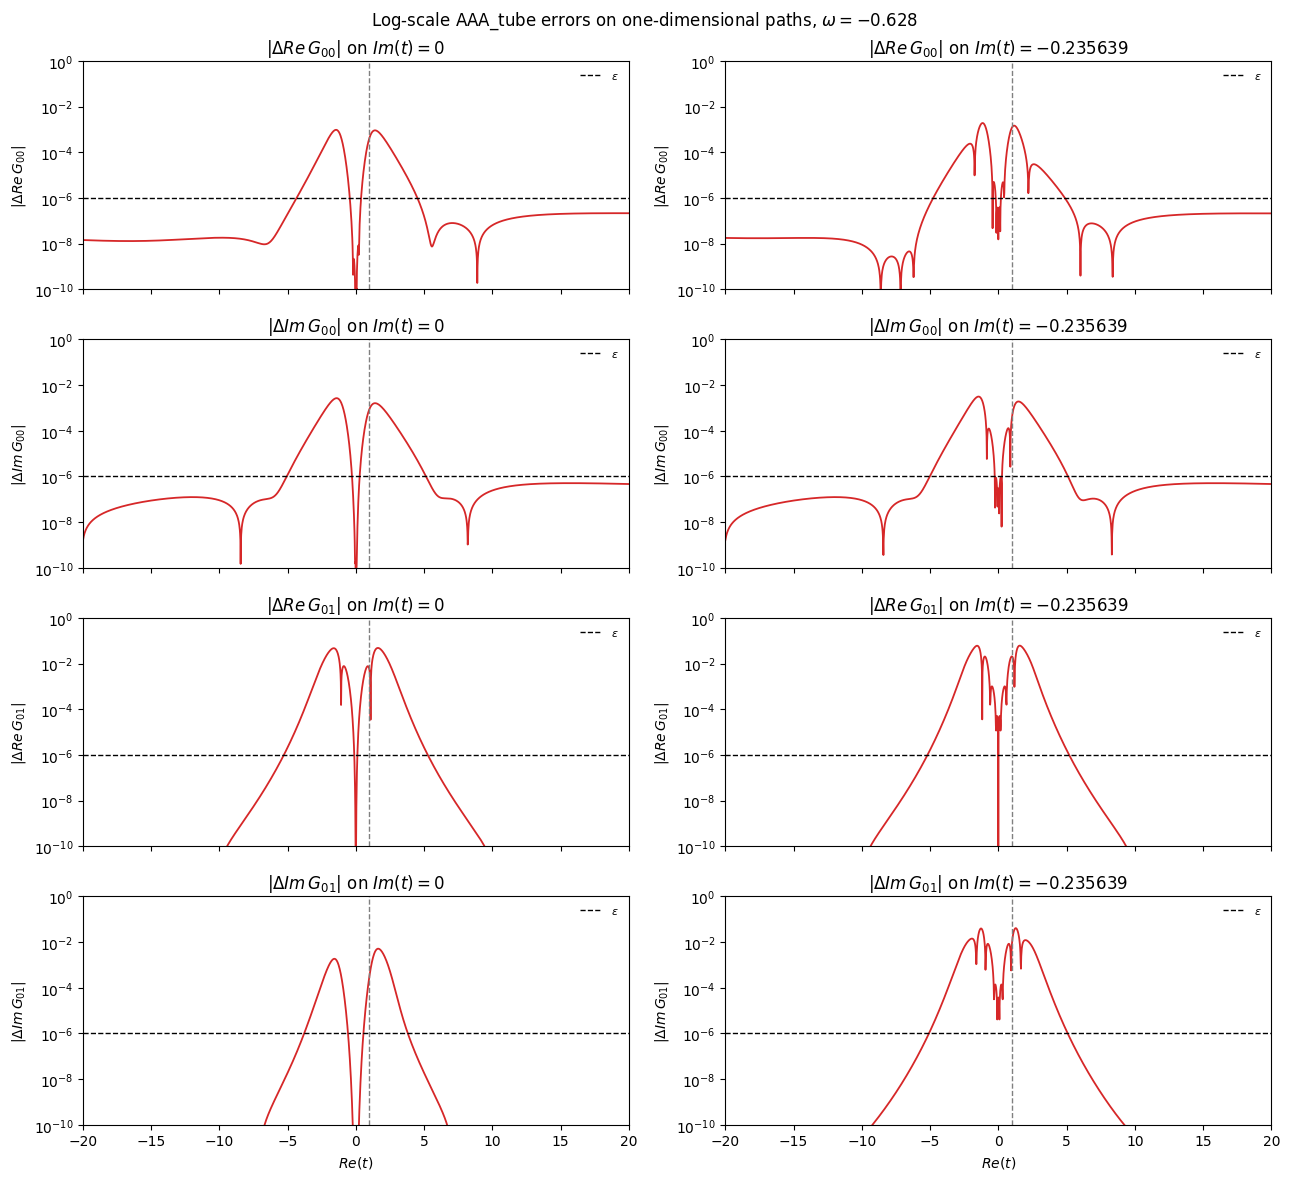

In [52]:
# Log-scale errors for the one-dimensional paths.
line_error_components = [
    (
        np.abs(G00_aaa_line_real.real - G_exact_line_real[:, 0, 0].real),
        np.abs(G00_aaa_line_complex.real - G_exact_line_complex[:, 0, 0].real),
        r"$|\Delta Re\,G_{00}|$",
    ),
    (
        np.abs(G00_aaa_line_real.imag - G_exact_line_real[:, 0, 0].imag),
        np.abs(G00_aaa_line_complex.imag - G_exact_line_complex[:, 0, 0].imag),
        r"$|\Delta Im\,G_{00}|$",
    ),
    (
        np.abs(G01_aaa_line_real.real - G_exact_line_real[:, 0, 1].real),
        np.abs(G01_aaa_line_complex.real - G_exact_line_complex[:, 0, 1].real),
        r"$|\Delta Re\,G_{01}|$",
    ),
    (
        np.abs(G01_aaa_line_real.imag - G_exact_line_real[:, 0, 1].imag),
        np.abs(G01_aaa_line_complex.imag - G_exact_line_complex[:, 0, 1].imag),
        r"$|\Delta Im\,G_{01}|$",
    ),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for row, (err_real, err_complex, title) in enumerate(line_error_components):
    axes[row, 0].semilogy(t_line_real, err_real, color="tab:red", linewidth=1.3)
    axes[row, 0].axhline(epsilon, color="k", linestyle="--", linewidth=1, label=r"$\epsilon$")
    axes[row, 0].set_title(title + r" on $Im(t)=0$")

    axes[row, 1].semilogy(t_line_real, err_complex, color="tab:red", linewidth=1.3)
    axes[row, 1].axhline(epsilon, color="k", linestyle="--", linewidth=1, label=r"$\epsilon$")
    axes[row, 1].set_title(title + rf" on $Im(t)={eta:g}$")

    for ax in axes[row, :]:
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(-T, T)
        ax.set_ylim(1e-10, 1)
        ax.set_ylabel(title)
        ax.legend(frameon=False, fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$Re(t)$")

fig.suptitle(rf"Log-scale AAA_tube errors on one-dimensional paths, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()
